In [2]:
pip install contextily matplotlib-scalebar rasterio pyproj


   ---------------- ----------------------- 2/5 [geopy]
   ---------------------------------------- 5/5 [contextily]

Note: you may need to restart the kernel to use updated packages.


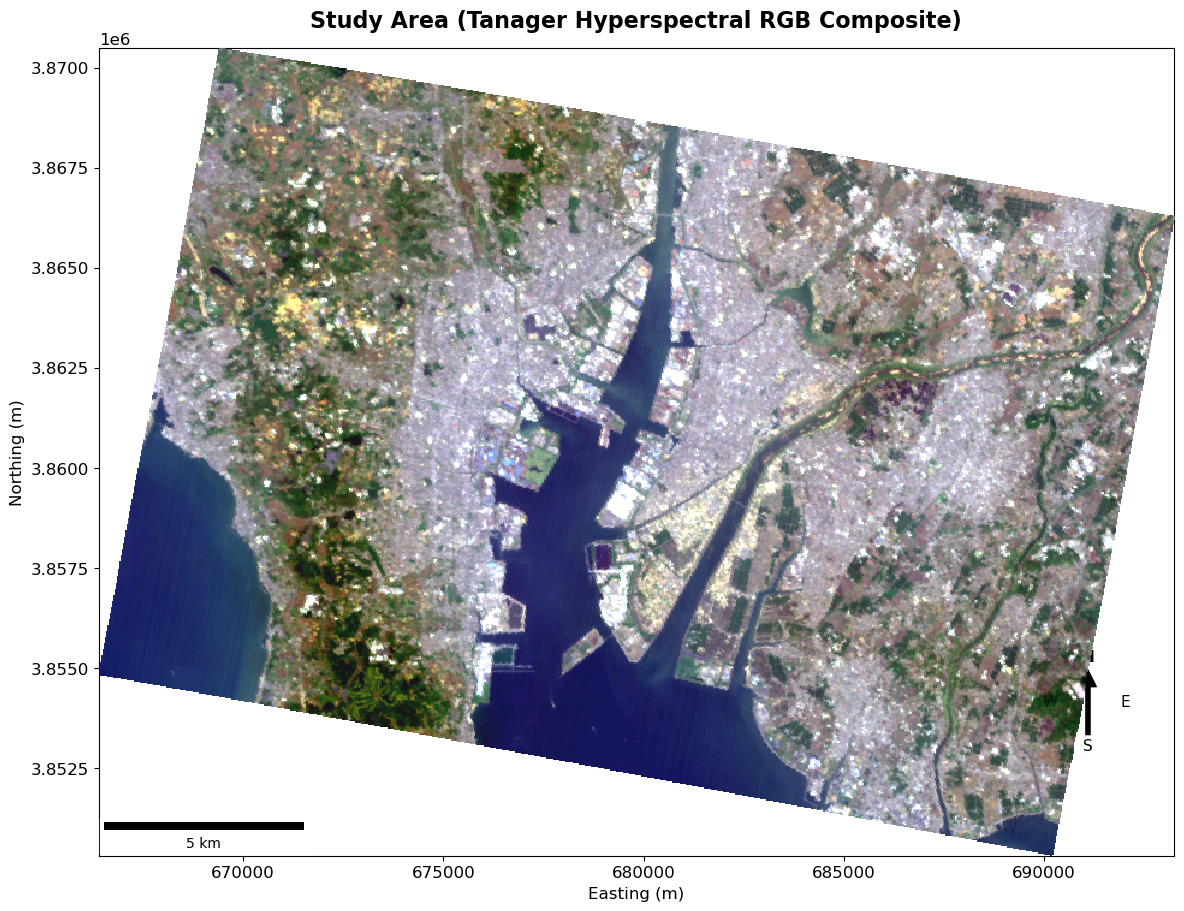

Saved to:
D:\TENAGER HYPERSPECTRAL DATA\JAPAN\study_area_map.png


In [4]:
# =============================================================================
# PUBLICATION-QUALITY STUDY AREA MAP
# =============================================================================

from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from rasterio.transform import from_origin
from rasterio.plot import plotting_extent
from rasterio.warp import transform_bounds
from matplotlib_scalebar.scalebar import ScaleBar
from pyproj import CRS

# =============================================================================
# PATHS
# =============================================================================

DATA_DIR = Path(r"D:\TENAGER HYPERSPECTRAL DATA\JAPAN")
HDF_FILE = DATA_DIR / "20250503_020525_16_4001_ortho_sr_hdf5.h5"

OUTPUT = DATA_DIR / "study_area_map.png"

# =============================================================================
# READ IMAGE
# =============================================================================

with h5py.File(HDF_FILE, "r") as f:

    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]
    nodata = f["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]

cube = np.transpose(cube, (1,2,0))

# =============================================================================
# RGB COMPOSITE
# =============================================================================

rgb = cube[:,:, [60,35,15]].astype(np.float32)

rgb[nodata!=0] = np.nan

# =============================================================================
# CONTRAST STRETCH (2-98 Percentile)
# =============================================================================

for i in range(3):

    band = rgb[:,:,i]

    p2, p98 = np.nanpercentile(band,[2,98])

    band = (band-p2)/(p98-p2)

    rgb[:,:,i] = np.clip(band,0,1)

# =============================================================================
# GAMMA CORRECTION
# =============================================================================

gamma = 0.85
rgb = rgb**gamma

# =============================================================================
# GEOREFERENCE
# =============================================================================

pixel_size = 30

xmin = 666390
xmax = 693240

ymax = 3870480
ymin = 3850320

transform = from_origin(
    xmin,
    ymax,
    pixel_size,
    pixel_size
)

extent = plotting_extent(rgb[:,:,0], transform)

# =============================================================================
# FIGURE
# =============================================================================

plt.rcParams.update({

    "font.size":12,
    "axes.titlesize":16,
    "axes.labelsize":12

})

fig, ax = plt.subplots(figsize=(12,10))

# =============================================================================
# OSM BASEMAP
# =============================================================================

xmin3857, ymin3857, xmax3857, ymax3857 = transform_bounds(
    CRS.from_epsg(32653),
    CRS.from_epsg(3857),
    xmin,ymin,xmax,ymax
)

import contextily as ctx

ctx.add_basemap(
    ax,
    crs="EPSG:32653",
    source=ctx.providers.Esri.WorldImagery,
    attribution=False,
    zorder=0
)

# =============================================================================
# RGB IMAGE
# =============================================================================

ax.imshow(
    rgb,
    extent=extent,
    interpolation="nearest",
    alpha=0.92,
    zorder=5
)

# =============================================================================
# GRID
# =============================================================================

ax.grid(
    color="white",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7
)

# =============================================================================
# SCALE BAR
# =============================================================================

scalebar = ScaleBar(
    dx=1,
    units="m",
    length_fraction=0.25,
    location="lower left",
    box_alpha=0.8,
    color="black",
    font_properties={"size":10}
)

ax.add_artist(scalebar)

# =============================================================================
# NORTH ARROW
# =============================================================================

x = 0.92
y = 0.15

ax.annotate(
    "",
    xy=(x,y+0.08),
    xytext=(x,y),
    xycoords="axes fraction",
    arrowprops=dict(
        facecolor="black",
        width=3,
        headwidth=12
    )
)

ax.text(x,y+0.09,"N",ha="center",transform=ax.transAxes,
        fontsize=12,fontweight="bold")

ax.text(x,y-0.02,"S",ha="center",transform=ax.transAxes,
        fontsize=11)

ax.text(x-0.035,y+0.035,"W",ha="center",transform=ax.transAxes,
        fontsize=11)

ax.text(x+0.035,y+0.035,"E",ha="center",transform=ax.transAxes,
        fontsize=11)

# =============================================================================
# LABELS
# =============================================================================

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.set_title(
    "Study Area (Tanager Hyperspectral RGB Composite)",
    pad=15,
    fontweight="bold"
)

# =============================================================================
# LIMITS
# =============================================================================

ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)

# =============================================================================
# SAVE
# =============================================================================

plt.tight_layout()

plt.savefig(
    OUTPUT,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{OUTPUT}")

In [5]:
# =============================================================================
# PART 1
# TANAGER STUDY AREA MAP
# Read Image + Enhance RGB + Reproject to Web Mercator
# =============================================================================

from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from rasterio.transform import from_origin
from rasterio.crs import CRS
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling,
)

from matplotlib_scalebar.scalebar import ScaleBar

# =============================================================================
# FILE PATH
# =============================================================================

DATA_DIR = Path(r"D:\TENAGER HYPERSPECTRAL DATA\JAPAN")

HDF_FILE = DATA_DIR / "20250503_020525_16_4001_ortho_sr_hdf5.h5"

OUTPUT = DATA_DIR / "Study_Area_Map.png"

# =============================================================================
# READ HDF5
# =============================================================================

print("Reading Tanager image...")

with h5py.File(HDF_FILE, "r") as f:

    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]

    nodata = f["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]

cube = np.transpose(cube, (1, 2, 0))

print("Cube shape:", cube.shape)

# =============================================================================
# RGB COMPOSITE
# =============================================================================

# Band selection
# R = 60
# G = 35
# B = 15

rgb = cube[:, :, [60, 35, 15]].astype(np.float32)

rgb[nodata != 0] = np.nan

# =============================================================================
# CONTRAST STRETCH
# =============================================================================

print("Applying percentile stretch...")

for i in range(3):

    band = rgb[:, :, i]

    low = np.nanpercentile(band, 2)

    high = np.nanpercentile(band, 98)

    band = (band - low) / (high - low)

    rgb[:, :, i] = np.clip(band, 0, 1)

# =============================================================================
# GAMMA CORRECTION
# =============================================================================

gamma = 0.85

rgb = rgb ** gamma

# =============================================================================
# IMAGE INFORMATION
# =============================================================================

pixel_size = 30.0

xmin = 666390.0
xmax = 693240.0

ymax = 3870480.0
ymin = 3850320.0

width = rgb.shape[1]
height = rgb.shape[0]

transform = from_origin(
    xmin,
    ymax,
    pixel_size,
    pixel_size,
)

src_crs = CRS.from_epsg(32653)

dst_crs = CRS.from_epsg(3857)

# =============================================================================
# CALCULATE OUTPUT TRANSFORM
# =============================================================================

print("Reprojecting image...")

dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs,
    dst_crs,
    width,
    height,
    xmin,
    ymin,
    xmax,
    ymax,
)

rgb3857 = np.zeros(
    (
        dst_height,
        dst_width,
        3,
    ),
    dtype=np.float32,
)

# =============================================================================
# REPROJECT RGB
# =============================================================================

for b in range(3):

    reproject(
        source=rgb[:, :, b],
        destination=rgb3857[:, :, b],
        src_transform=transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
    )

# =============================================================================
# MAP EXTENT
# =============================================================================

left = dst_transform.c

top = dst_transform.f

right = left + dst_width * dst_transform.a

bottom = top + dst_height * dst_transform.e

extent = (
    left,
    right,
    bottom,
    top,
)

print("Done.")
print("Projected size:", rgb3857.shape)
print("Ready for plotting.")

Reading Tanager image...
Cube shape: (672, 895, 426)
Applying percentile stretch...
Reprojecting image...
Done.
Projected size: (691, 906, 3)
Ready for plotting.


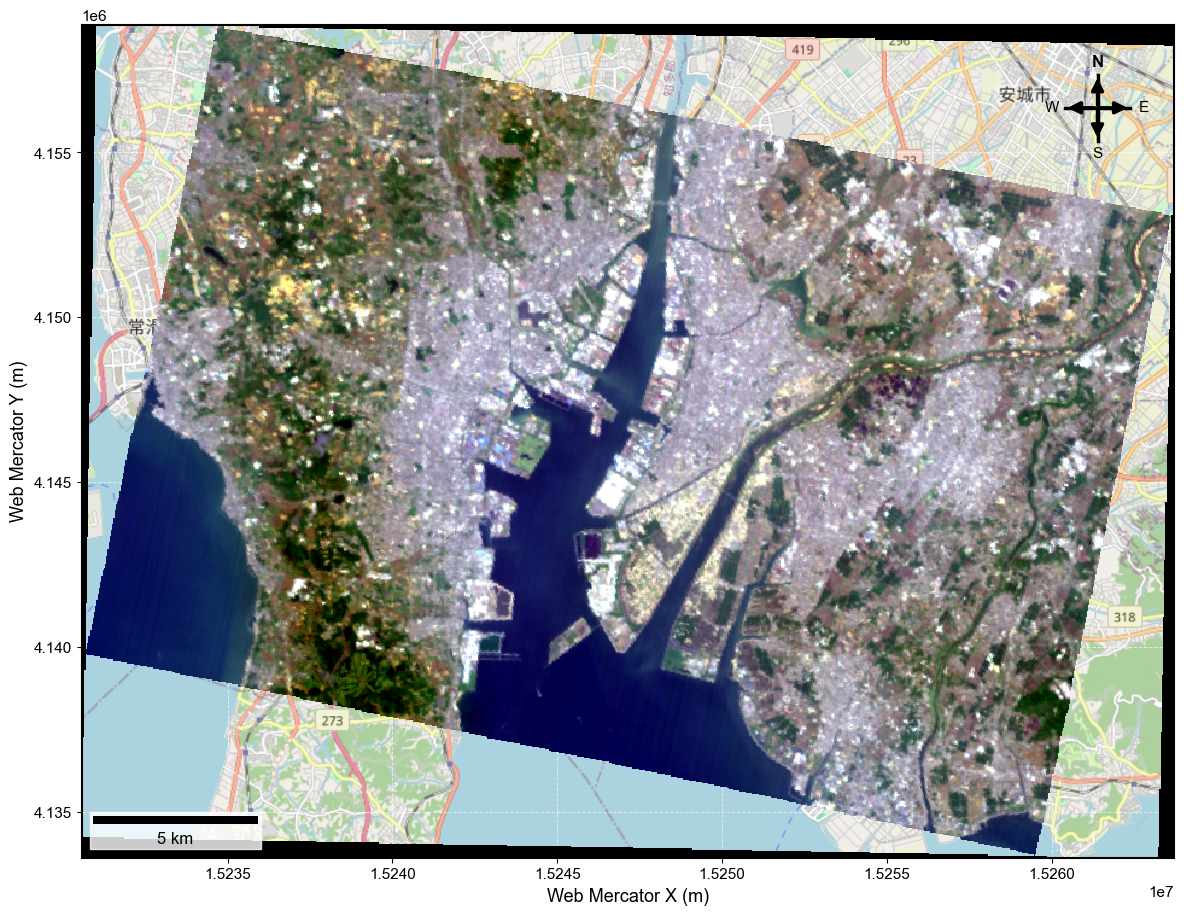

Study area map saved successfully:
D:\TENAGER HYPERSPECTRAL DATA\JAPAN\Study_Area_Map.png


In [11]:
# =============================================================================
# PART 2
# Plot + Esri Basemap + Cartographic Elements + Save PNG
# =============================================================================

import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# =============================================================================
# FIGURE STYLE
# =============================================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(12, 10))

# =============================================================================
# PLOT RGB IMAGE
# =============================================================================

ax.imshow(
    rgb3857,
    extent=extent,
    interpolation="nearest",
    zorder=5
)

# =============================================================================
# BASEMAP
# =============================================================================

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        attribution=False,
        crs="EPSG:3857",
        zoom="auto",
        zorder=0,
    )
except Exception as e:
    print("Basemap could not be loaded.")
    print(e)

#OPTION
#source=ctx.providers.Esri.WorldStreetMap
#source=ctx.providers.Esri.WorldImagery
#source=ctx.providers.CartoDB.Positron
#source=ctx.providers.CartoDB.DarkMatter
#source=ctx.providers.OpenStreetMap.Mapnik
#source=ctx.providers.Esri.WorldTerrain

# =============================================================================
# MAP EXTENT
# =============================================================================

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

# =============================================================================
# GRID
# =============================================================================

ax.grid(
    color="white",
    linestyle="--",
    linewidth=0.7,
    alpha=0.6,
)

# =============================================================================
# SCALE BAR
# =============================================================================

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.25,
    box_alpha=0.8,
    border_pad=0.5,
)

ax.add_artist(scalebar)

# =============================================================================
# NORTH ARROW (ALL BLACK - TOP RIGHT)
# =============================================================================

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# position (top-right in axes fraction style converted to map coords)
cx = xmin + (xmax - xmin) * 0.93
cy = ymin + (ymax - ymin) * 0.90

size = (xmax - xmin) * 0.03
lw = 2.5

# cross lines
ax.plot([cx, cx], [cy - size, cy + size], color="black", linewidth=lw, zorder=100)
ax.plot([cx - size, cx + size], [cy, cy], color="black", linewidth=lw, zorder=100)

# arrow heads
for dx, dy in [(0, size), (0, -size), (size, 0), (-size, 0)]:
    ax.annotate(
        "",
        xy=(cx + dx, cy + dy),
        xytext=(cx, cy),
        arrowprops=dict(
            arrowstyle="-|>",
            lw=lw,
            color="black",
            mutation_scale=18
        ),
        zorder=101
    )

# labels
label_offset = size * 1.4

ax.text(cx, cy + label_offset, "N", ha="center", va="center",
        fontsize=12, fontweight="bold", color="black", zorder=102)
ax.text(cx, cy - label_offset, "S", ha="center", va="center",
        fontsize=11, color="black", zorder=102)
ax.text(cx + label_offset, cy, "E", ha="center", va="center",
        fontsize=11, color="black", zorder=102)
ax.text(cx - label_offset, cy, "W", ha="center", va="center",
        fontsize=11, color="black", zorder=102)

# =============================================================================
# TITLE
# =============================================================================

ax.set_title("", fontweight="bold", pad=15)

# =============================================================================
# AXIS LABELS
# =============================================================================

ax.set_xlabel("Web Mercator X (m)")
ax.set_ylabel("Web Mercator Y (m)")

# =============================================================================
# FRAME
# =============================================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# =============================================================================
# SAVE
# =============================================================================

plt.tight_layout()

plt.savefig(
    OUTPUT,
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print("=" * 60)
print("Study area map saved successfully:")
print(OUTPUT)
print("=" * 60)